# Solving our example circuit using Qiskit

In this notebook we will use Qiskit to build this simple quantum circuit we analyzed during our previous lab session:

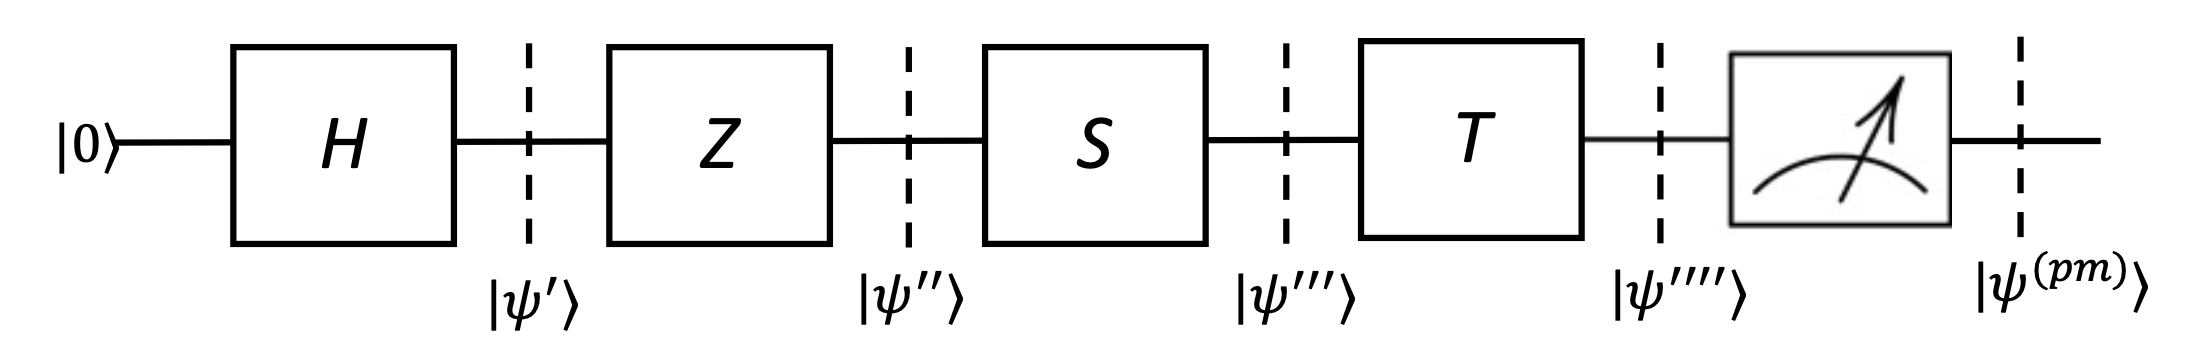

In [34]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, Aer
from qiskit.visualization import plot_bloch_multivector, plot_histogram

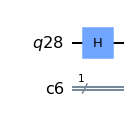

In [39]:
# QuantumRegister(size) is a reference to the qubits that will compose our circuit.
# In our case we define a single qubit register:
psi = QuantumRegister(1)

# We also define the classical register that will store the measurement results
out = ClassicalRegister(1)

# Finally, we define our QuantumCircuit. It takes two parameters, the quantum and classical registers.
circ = QuantumCircuit(psi, out)

# apply Hadamard to the circuit's qubit 0.
circ.h(0)

circ.draw('mpl')

## Choosing a backend

Since we want to analyze all the intermediate states $\vert\psi'\rangle, \vert\psi''\rangle, \vert\psi'''\rangle, \vert\psi''''\rangle$, we will run the circuit after the application of each gate, and follow the evolution of the state vector.

Question: "Didn't I say that executing quantum circuits simply means applying one or more gates and collecting some measurement results?"

Yes, but if we use a statevector simulator, we can "cheat", and print the quantum state of the qubit at any time, without any measurement.

In [40]:
# We ask our provider (in this case Aer), to provide us with a backend which is a statevector simulator.
backend = Aer.get_backend('statevector_simulator')

### $\vert\psi'\rangle$ on the Bloch sphere

In [41]:
# We create our job by running the circuit and collect the output state
job = backend.run(circ)
result = job.result()
state  = result.get_statevector(circ)
print(state)

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


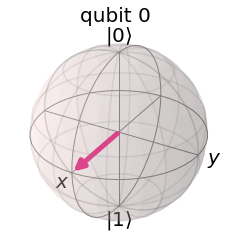

In [42]:
# We print our state vector on the Bloch sphere
plot_bloch_multivector(state)

### Let's go on and add Z gate to the circuit

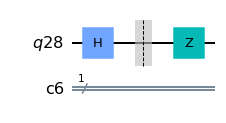

In [43]:
# a barrier is a graphic tool, it does nothing else.
circ.barrier()

circ.z(0)
circ.draw('mpl')

### $\vert\psi''\rangle$ on the Bloch sphere

In [44]:
result = backend.run(circ).result()
state  = result.get_statevector(circ)
print(state) # |->

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


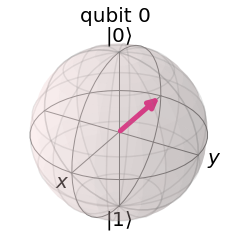

In [45]:
plot_bloch_multivector(state)

### Now we add S gate...

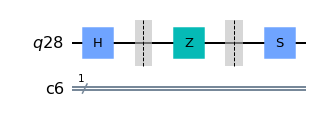

In [46]:
circ.barrier()
circ.s(0)
circ.draw(output="mpl")

In [47]:
result = backend.run(transpile(circ, backend)).result()
state  = result.get_statevector(circ)
print(state)

Statevector([ 0.70710678+0.j        , -0.        -0.70710678j],
            dims=(2,))


### $\vert\psi'''\rangle$ on the Bloch sphere

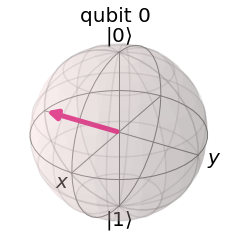

In [48]:
plot_bloch_multivector(state)

### Finally the last gate T

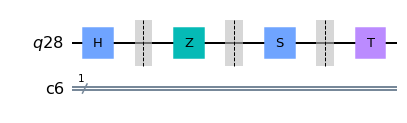

In [49]:
circ.barrier()
circ.t(0)
circ.draw(output="mpl")

### $\vert\psi''''\rangle$ on the Bloch sphere

In [50]:
result = backend.run(circ).result()
state  = result.get_statevector(circ)
print(state)

Statevector([0.70710678+0.j , 0.5       -0.5j],
            dims=(2,))


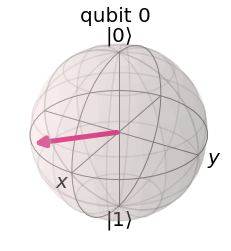

In [51]:
plot_bloch_multivector(state)

## Now we execute the circuit in a "proper" way

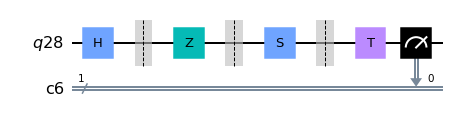

In [52]:
# Add a measurement gate at the end
circ.measure(psi, out)
circ.draw(output="mpl")

### According to the algebra we did during the last lab, we should get $\vert0\rangle$ or $\vert1\rangle$ with 50% probability

In [53]:
# Use Aer as provider and get a qasm simulator
backend = Aer.get_backend('qasm_simulator')

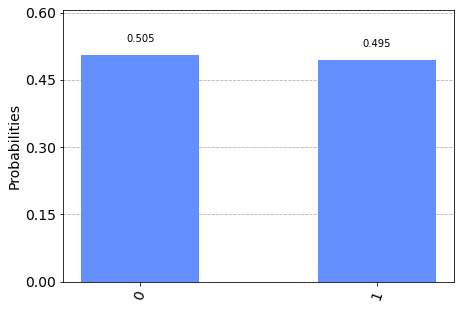

In [55]:
result = backend.run(circ, shots=2048).result()
counts = result.get_counts()
plot_histogram(counts)